# Report: Analysis of energy and device usage throughout the day

This report aims to use the provided data on electricity and gas usage, as well as the data on the devices that were installed in the house to provide an overview of the consumption of gas and electricity throughout the day, as well as to analyse how device usage differs between day and night. Thus answering the following questions:

- Does average electricity use change throughout the day?
- Is it possible to identify intervals of time when nobody's home?

We can start by importing the home messages file and creating the "myhome" database. Then we can insert the files into the database and return the data from the database as a pandas dataframe.

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import title

from home_messages_db import *
import datetime
import random
from scipy import stats
pd.options.mode.copy_on_write = True

In [2]:
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

In [ ]:
def handle_dates_in_df(df):
    """
    Takes a dataframe which contains dates as epochs, turns them into dates, hours and minutes.
    """
    df["date"] = df["epoch"].apply(float).apply(timestamp_into_ams_time).dt.date
    df["time"] = df["epoch"].apply(int).apply(timestamp_into_ams_time).dt.strftime("%H:%M")
    df[["hour", "minute"]] = df.loc[:,"time"].str.split(":", n = 1, expand=True)
    df["hour"] = df["hour"].apply(int)
    return df

First lets insert the files into the database

In [4]:
# This code takes around 1 minute to run
db.insert_all()

Globbing path: /Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e*
Globbing path: /Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/smartthings/smartthings*
Globbing path: /Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g*


And now fetch them and insert them into a pandas dataframe

In [5]:
energy_usage = db.return_whole_table("P1e")
energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2
0,1647612900,6506.377,5313.255,0.0,0.0
1,1647613800,6506.377,5313.516,0.0,0.0
2,1647614700,6506.377,5314.241,0.0,0.0
3,1647615600,6506.377,5314.800,0.0,0.0
4,1647616500,6506.377,5314.933,0.0,0.0


### Question 1: Does average electricity use change throughout the day?

The first kind of analysis is about the energy usage throughout the day, which means we first need to convert the epochs (so unix time) into datetime and extract the times separately from the whole date.

In [ ]:
energy_usage = handle_dates_in_df(energy_usage)
energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,15:15
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,15:30
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,15:45
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,16:00
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,16:15


Since the energy usage columns indicate the overall energy usage for low and high cost hours we need to create a new column that checks the usage at each timepoint to the previous timepoint for both columns and then takes the sum of those two values as the consumption for that period.

In [10]:
energy_usage["usage"] = energy_usage.loc[:,"Electricity_imported_T1"].diff() + energy_usage.loc[:,"Electricity_imported_T2"].diff()
energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time,hour,minute,usage
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,15:15,15,15,NaN
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,15:30,15,30,0.261
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,15:45,15,45,0.725
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,16:00,16,00,0.559
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,16:15,16,15,0.133


Now we can use a lineplot to see how energy consumption varies roughly throughout the day. The red lines mark a shift from high-cost to low-cost hours / vice versa.

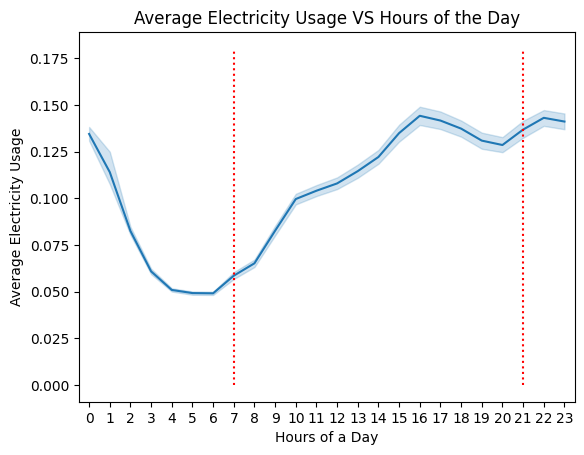

In [14]:
ax = sns.lineplot(energy_usage, x = "hour", y = "usage", estimator= "mean")
plt.xticks(np.arange(0,24, step = 1), rotation = 0, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.18, linestyles= "dotted", color = "red")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Hours of the Day")
plt.show()

Looking at the plot, we can see quite a big difference between the low cost and high cost hours. We can see that from around 00:00 to 05:00 the consumption drops by a significant amount. It then stabilizes at a low level before increasing steadily throughout the day during the high cost hours. Peak consumption happens at around 16:00, at which point consumption seems to stabilize until the end of the day. This would make sense for an average family home. 

It's likely the family starts the day around 06:00 or 07:00, which is why consumption would increase from that point onward. If one or more people then stay home, it would make sense that consumption would keep increasing as appliances start getting used. We would expect 16:00 to 17:00 to be the time the average person comes home, which is why we would then see a peak until the rest of the day, until everyone goes to bed and the family stops actively consuming any energy. This is also reflected in the smaller confidence intervals during the night, as consumption around those hours is not likely to deviate it a lot because people will pretty much always be asleep during those hours.

We can now check the same for Gas consumption and observe differences and similarities.

In [16]:
gas_usage = db.return_whole_table("P1g")

gas_usage = handle_dates_in_df(gas_usage)

gas_usage["usage"] = gas_usage.loc[:,"Total_gas_used"].diff()
gas_usage.head()

,epoch,Total_gas_used,date,time,hour,minute,usage
0,1647612900,3422.015,2022-03-18,15:15,15,15,NaN
1,1647613800,3422.028,2022-03-18,15:30,15,30,0.013
2,1647614700,3422.033,2022-03-18,15:45,15,45,0.005
3,1647615600,3422.065,2022-03-18,16:00,16,00,0.032
4,1647616500,3422.089,2022-03-18,16:15,16,15,0.024


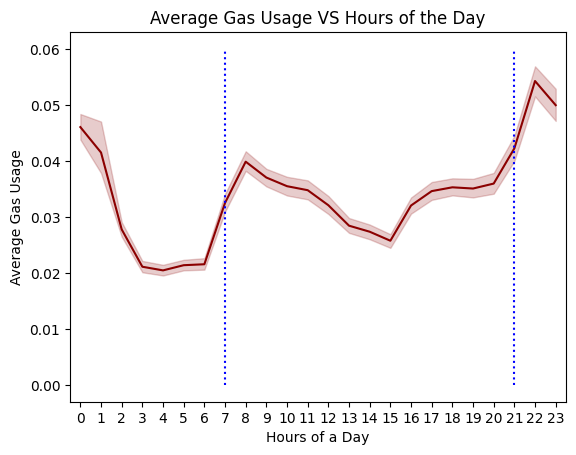

In [18]:
ax = sns.lineplot(gas_usage, x = "hour", y = "usage", estimator= "mean", color = "darkred")
plt.xticks(np.arange(0,24, step = 1), rotation = 0, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.06, linestyles= "dotted", color = "blue")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Gas Usage", title = "Average Gas Usage VS Hours of the Day")
plt.show()

Once again the blue lines indicate the change between low-cost to high-cost hours and vice versa.

Looking at the plot we see some differences as well as some similarities. What we can evidently observe is the dip after 00:00 and the rather strong increase around 06:00 and 07:00. One major difference is that we do not see a consistent increase throughout the day, but rather a small dip around 14:00 and an increase after 20:00. A likely explanation could be that due to the decreased usage throughout the night, once people start waking up, the heating in the house is turned on, however after that to keep the temperature constant, it is not necessary to further increase the heating. As the temperature outside increases, the opposite might actually be the case which could explain the dip around 14:00. Only when it gets later and temperatures outside start to drop would this be the case, which would then explain the increase of gas usage after 20:00.

### Question 2: Is it possible to identify intervals of time when nobody is home? 


There are multiple ways of approaching this question. First of all, we might hypothesise that during intervals where nobody is home, electricity consumption might be significantly lower than when people are at home. Secondly, gas usage might also be significantly lower when nobody is home -- especially during the coldest days of winter. Third, since smartthings contains data from motion-activated sensors and other devices which need to be used actively in order to be active, if there are large intervals of time when these devices are not used, we can assume that nobody was home to use them. 

#### 2.a: Can we see intervals of time when electricity consumption dips when looking at single dates?

In order to investigate this question, we can take a look at data from a random selection of days throughout the period for which we have data. As such, we draw a random sample of 20 days. Since we cannot be certain that this household does not use some electric devices for heating (such as space-heaters, or electric floor-heating in parts of the house), and since for later questions we will be investigating gas use to answer the bigger question, we use a random sample of dates from only cold months.

In [23]:
max(energy_usage["date"])

cold_months_24 = energy_usage[((energy_usage["date"] >= datetime.date(2024,11,1)) | (energy_usage["date"] <= datetime.date(2024,3,1))) & (energy_usage["date"] < datetime.date(2025,1,1)) & (energy_usage["date"] > datetime.date(2023,12,31))]
cold_months_23 = energy_usage[((energy_usage["date"] >= datetime.date(2023,11,1)) | (energy_usage["date"] <= datetime.date(2023,3,1))) & (energy_usage["date"] < datetime.date(2024,1,1)) & (energy_usage["date"] > datetime.date(2022,12,31))]
cold_months_22 = energy_usage[((energy_usage["date"] >= datetime.date(2022,11,1)) | (energy_usage["date"] <= datetime.date(2022,3,1))) & (energy_usage["date"] < datetime.date(2023,1,1)) & (energy_usage["date"] > datetime.date(2021,12,31))]


cold_months = pd.concat([cold_months_24, cold_months_23], ignore_index= True)
cold_months = pd.concat([cold_months, cold_months_22], ignore_index=True)

In [24]:
random.seed(203903)
random_days = random.sample(list(cold_months["date"]), k = 10)    

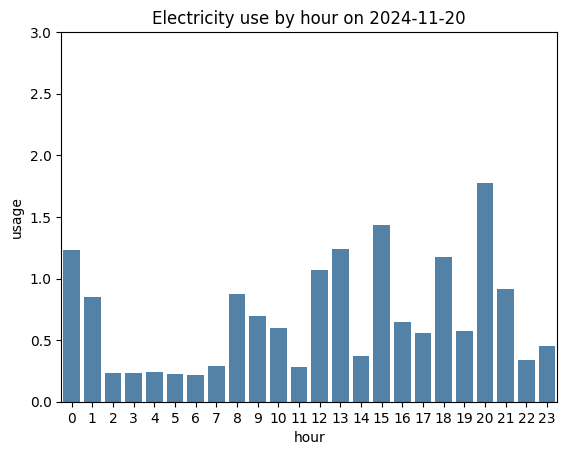

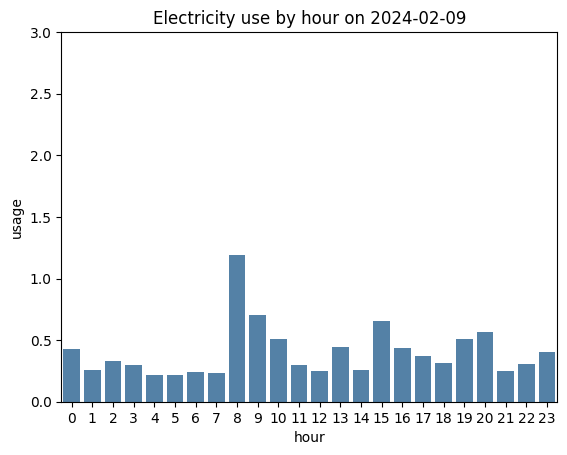

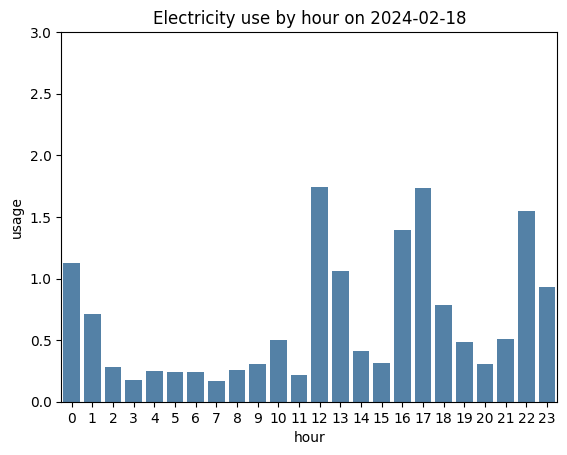

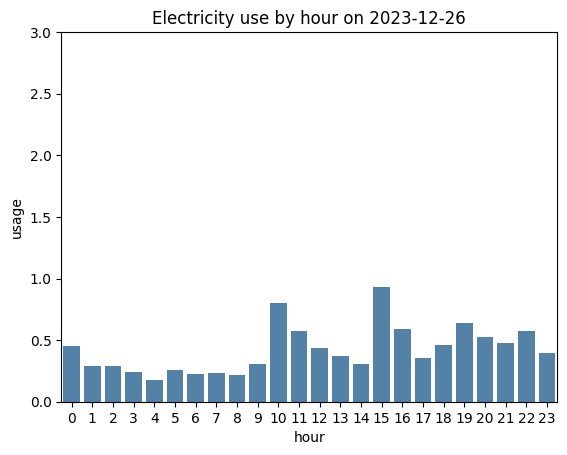

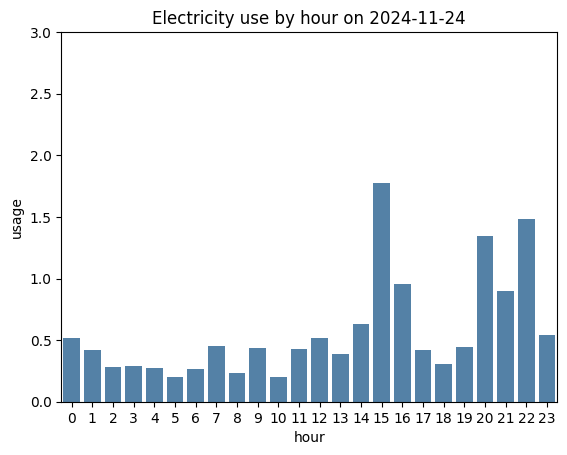

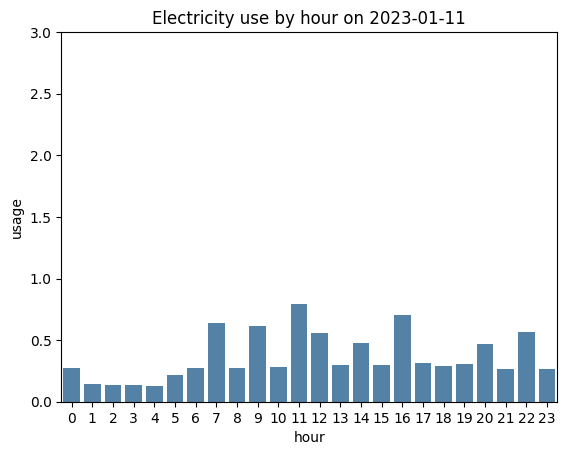

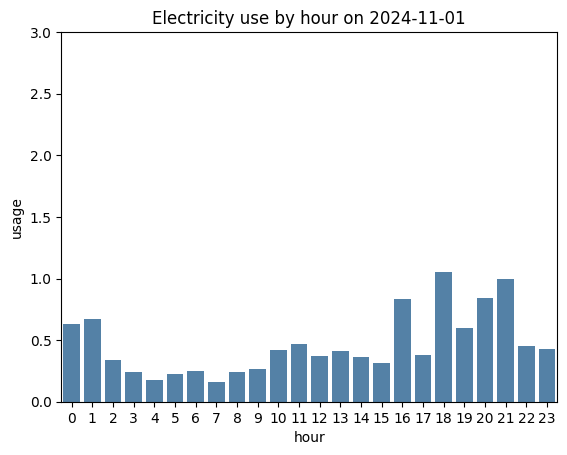

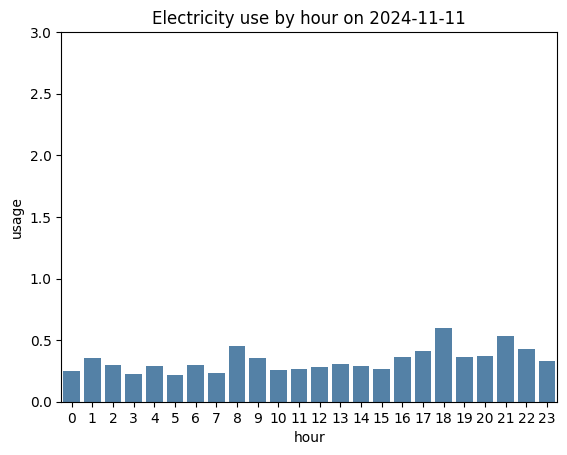

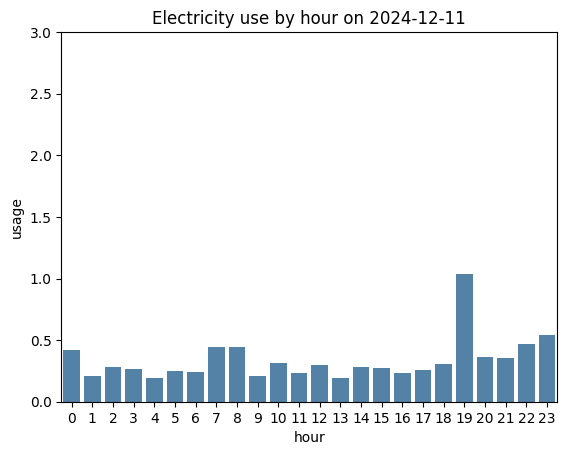

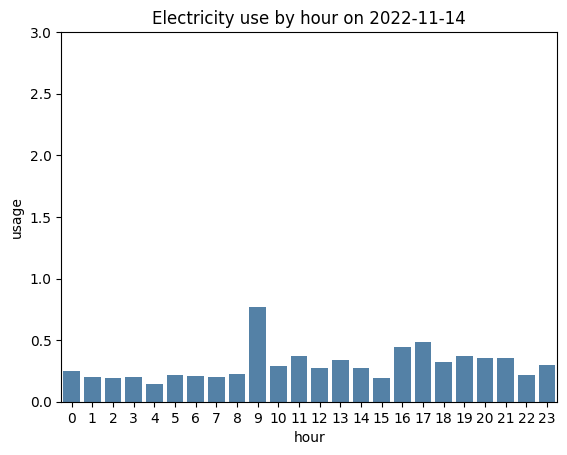

In [ ]:
cold_days = energy_usage[energy_usage["date"].isin(random_days)]

cold_days = cold_days[["date", "usage", "hour"]].groupby(["date", "hour"]).sum()

def create_day_barplot(df, date, color, energy, max_lim = 3):
    temp_df = df.loc[date]
    fig, ax = plt.subplots()
    ax.set_ylim(0,max_lim)
    plt.title(f"{energy} use by hour on {date}")
    sns.barplot(temp_df, x = "hour", y = "usage", ax = ax, color = color)

for date in random_days:
    create_day_barplot(cold_days, date, "steelblue", "Electricity")


#### 2.b: What is the average passive electricity use of the house?

When it comes to household electricity use, it is also common for devices (such as a fridge or ventilation system) to passively consume electricity. As such, energy usage for no time is likely to be zero. In order to assess what is likely to be the average passive electricity use, we can take the mean electricity use at a time when everyone in the household is likely to be asleep. As we can see in the lineplot from before (repeated below for convenience), the average electricity use for times between 02:00 and 05:00 is much lower than the average electricity use during other times of the day, through the whole period.

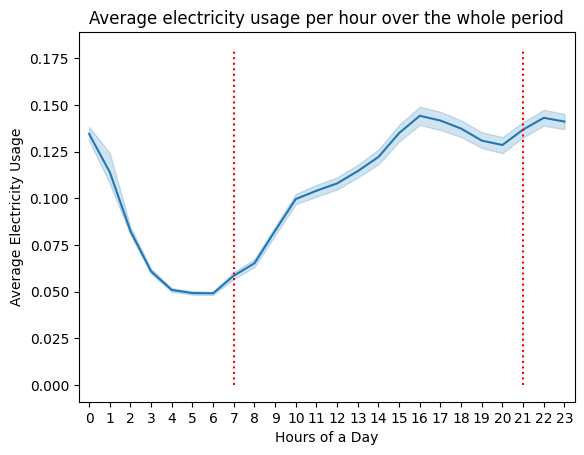

In [30]:
ax = sns.lineplot(energy_usage, x = "hour", y = "usage", estimator= "mean")
plt.xticks(np.arange(0,24, step = 1), rotation = 0, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.18, linestyles= "dotted", color = "red")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Electricity Usage", title = "Average electricity usage per hour over the whole period")
plt.show()


#### 2.c: Do the peaks in electricity use seen in the above graphs differ significantly from the passive electricity use estimates? (Hypothesis-testing using paired-samples t-test)

Thus, we can take electricity usage during (some) hours between 01:00 to 05:00 and treat it as a "reference value" for the passive electricity use for this house. Then, we can perform hypothesis-testing via a paired-sample t-test to check whether certain intervals of time have electricity usage which is significantly different than the passive consumption time intervals.

We can begin by checking one of the randomly sampled dates from above, 1st November 2024. 

There seems to be clear peaks of use around 15:00, 17:00 and 20:00, indicating that someone must have been home during those times. Is the electricity usage significantly different between 15:00 and 20:00 and between 01:00 and 05:00? For reference, we re-plot the barplot for this specific date below.

Then, is electricity usage significantly different between 09:00 and 14:00, when the lowest valley of electricity use during the daytime appears to have happened on this date?

In order to maximise the number of samples for the t-test, we use the electricity usage values in 15-minute-intervals instead of the 'binned' values by hour used in the barplots above.

In [31]:
def is_significant(test_use, reference_use):
    """
    Helper function for between_hour_t_test(). Runs the t-test. 
    
    Returns: 
        empty string (" ") if one-tailed test is significant at alpha = 0.01 
        or "not" if one-tailed test is not significant at alpha = 0.01
    """
    t_test = stats.ttest_rel(test_use["usage"], reference_use["usage"], alternative= "greater")
    p_value = t_test[1]
    if p_value > 0.01:
        return(" not ", p_value)
    else:
        return(" ", p_value)



def between_hour_t_test(day_df, peak_hours, possibly_absent_hours, reference_hours, energy):
    """
    Allows running a t-test to check whether a sample of energy use between a time interval is significantly greater than a
    sample of energy use between a different (reference) time interval. 

    Parameters:
        day_df: pd.DataFrame
            Which dataframe we want to sample energy usage from (should contain usage over 24 hour interval)
        peak_hours: list
            List of hours when we see peak usage
        possibly_absent_hours: list
            List of hours when we see lowest daytime usage
        reference_hours: list
            List of hours when the family is expected to be asleep
        energy: string
            What energy type we are checking (Electricity/Gas)
    """
    peak_use = day_df[day_df["hour"].isin(peak_hours)]
    passive_use = day_df[day_df["hour"].isin(reference_hours)]
    possibly_absent_use = day_df[day_df["hour"].isin(possibly_absent_hours)]
    significance_peak, p_val_peak = is_significant(peak_use, passive_use)
    print(f"{energy} use from {peak_hours[0]}:00 to {peak_hours[-1]}:00 is{significance_peak}significantly greater than passive {energy.lower()} use. p-value = {p_val_peak}")
    significance_absent, p_val_absent = is_significant(possibly_absent_use, passive_use)
    print(f"{energy} use from {possibly_absent_hours[0]}:00 to {possibly_absent_hours[-1]}:00 is{significance_absent}significantly greater than passive {energy.lower()} use. p-value = {p_val_absent}")



Electricity use from 15:00 to 20:00 is significantly greater than passive electricity use. p-value = 1.1826660348223322e-05
Electricity use from 9:00 to 14:00 is significantly greater than passive electricity use. p-value = 0.00387004351725927


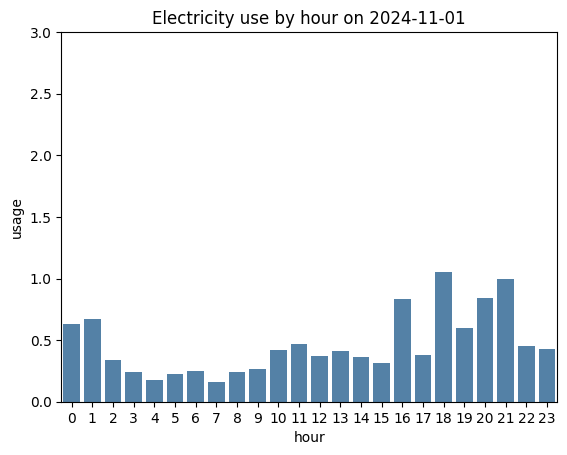

In [33]:
nov_1 = energy_usage[energy_usage["date"] == random_days[0]]
nov_1[["date", "time", "usage", "hour"]]

create_day_barplot(cold_days, datetime.date(2024,11,1), "steelblue", "Electricity")   
between_hour_t_test(nov_1, peak_hours=list(range(15,21)), possibly_absent_hours=list(range(9,15)), reference_hours=list(range(1,7)), energy = "Electricity")


The one-sided paired samples t-test above indicates that electricity use overnight (what we can consider the passive electricity use of the electrical devices in the house) is significantly lower than the use in both of the "peak" hours and in the "valley" hours, showing that it is unlikely that nobody was actively using electrical devices between those hours.

Another interesting date to consider is 24th November 2024 (2024-11-24). It appears that between the hours of 09:00 and 12:00, electricity use is relatively low, showing that perhaps during this time interval, nobody was home. On the other hand, clearly someone was home from 19:00 to 22:00. We can check if the electricity usage patterns between these two time intervals are significantly different from the overnight passive usage.

Indeed, the one-tailed t-test shows that electricity usage between 09:00 and 12:00 is not significantly greater than elecrticity usage overnight. As such, we cannot rule out the possibility that nobody was actively using electrical devices during that time-interval -- which could mean that this is a possible interval of nobody being at home.

Electricity use from 19:00 to 22:00 is significantly greater than passive electricity use. p-value = 0.0012870263988021084
Electricity use from 9:00 to 12:00 is not significantly greater than passive electricity use. p-value = 0.13477147661956962


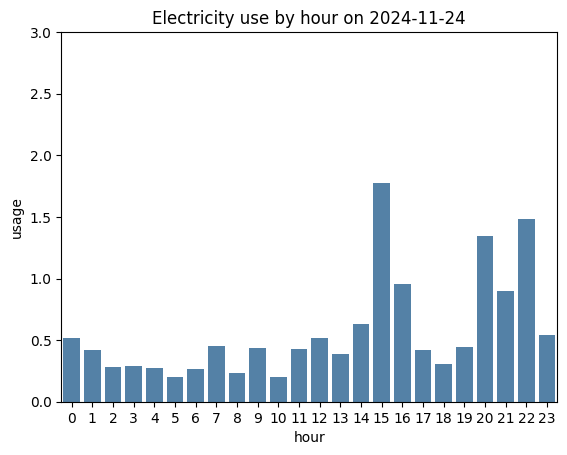

In [34]:
create_day_barplot(cold_days, datetime.date(2024,11,24), "steelblue", "Electricity")
nov_24 = energy_usage[energy_usage["date"] == datetime.date(2024,11,24)]
nov_24[["date", "time", "usage", "hour"]]
between_hour_t_test(nov_24, peak_hours=list(range(19,23)), possibly_absent_hours=list(range(9,13)), reference_hours=list(range(1,5)), energy = "Electricity")

Lastly, there are days where it is not clear whether anybody was home for any part of the day, judging by the fact that the electricity use does not fluctuate much throughout the day. One of these days is 11th November 2024 (2024-11-11).

The t-tests show that there is no significant difference in electricity usage between the early morning hours of 01:00 - 06:00 and the late morning to midday hours of 10:00 - 14:00, but the usage between 18:00 - 23:00 is significantly greater. As such, we cannot rule out that nobody was using electrical devices actively through the midday, whereas perhaps we can rule out that nobody was home between 18:00 and 22:00.

Electricity use from 18:00 to 22:00 is significantly greater than passive electricity use. p-value = 0.0030549481125122786
Electricity use from 10:00 to 14:00 is not significantly greater than passive electricity use. p-value = 0.4537129258954805


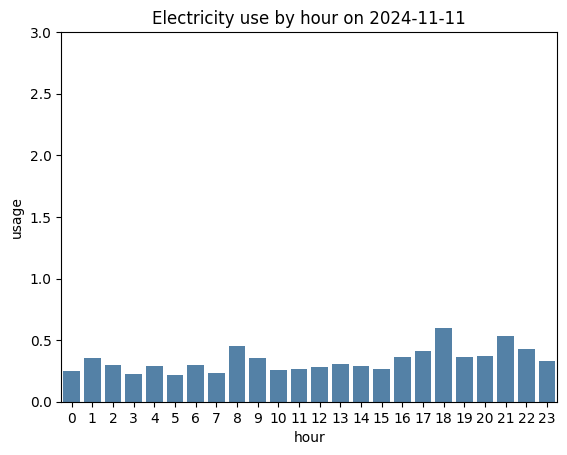

In [35]:
create_day_barplot(cold_days, datetime.date(2024,11,11), "steelblue", "Electricity")
nov_11 = energy_usage[energy_usage["date"] == datetime.date(2024,11,11)]
nov_11[["date", "time", "usage", "hour"]]
between_hour_t_test(nov_11, peak_hours=list(range(18,23)), possibly_absent_hours=list(range(10,15)), reference_hours=list(range(1,6)), energy = "Electricity")

#### 2.e: Can we see intervals of time when gas consumption dips when looking at single dates?


As with the previous question, the barplots below show that it is easy to spot intervals of time when gas usage increases or decreases. To see whether these intervals can help spot whether someone is home or not, we can check the same three dates as we investigated for electricity, and see whether the energy use patterns in gas are similar to those of electricity, and whether overnight usage is significantly different than certain intervals of the day. 

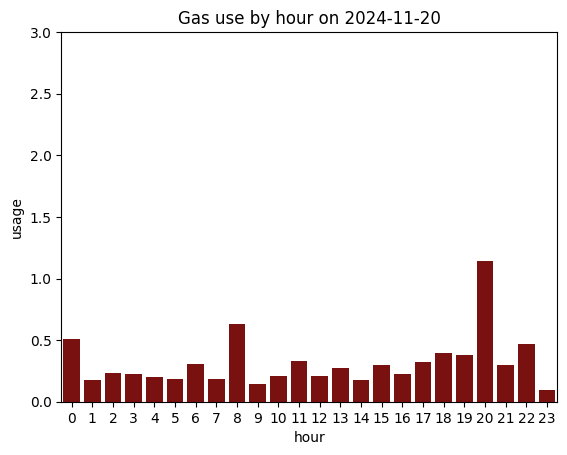

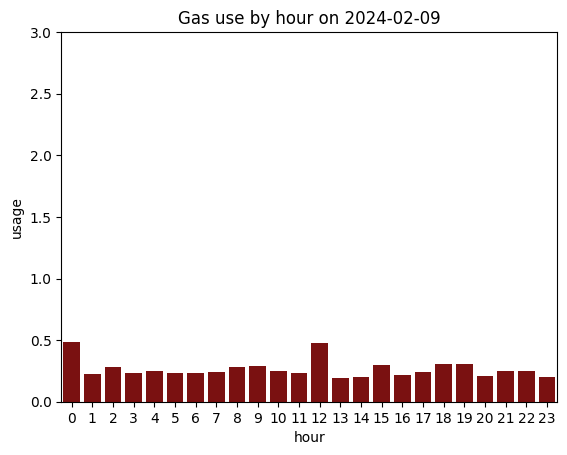

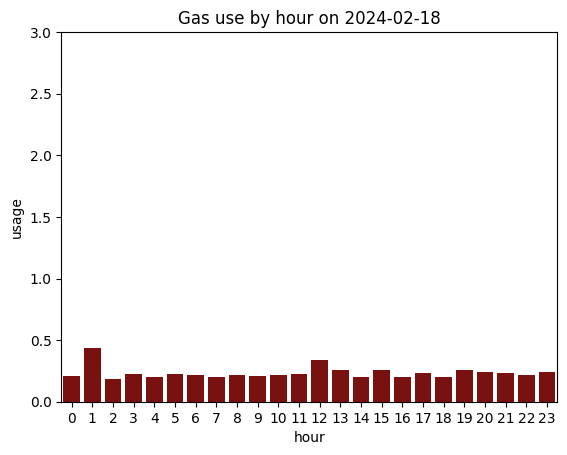

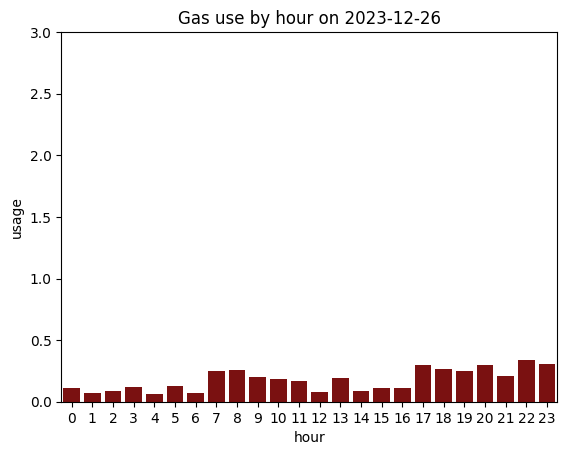

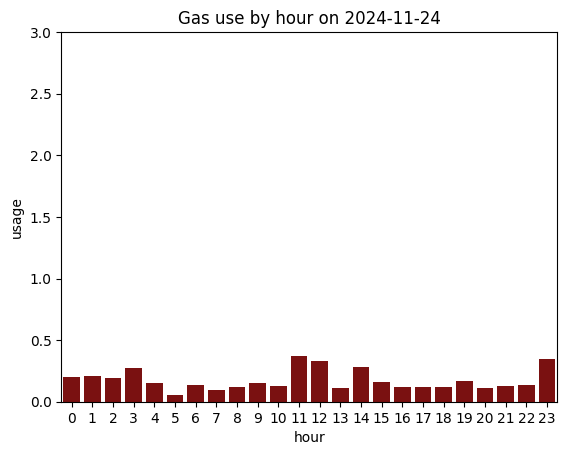

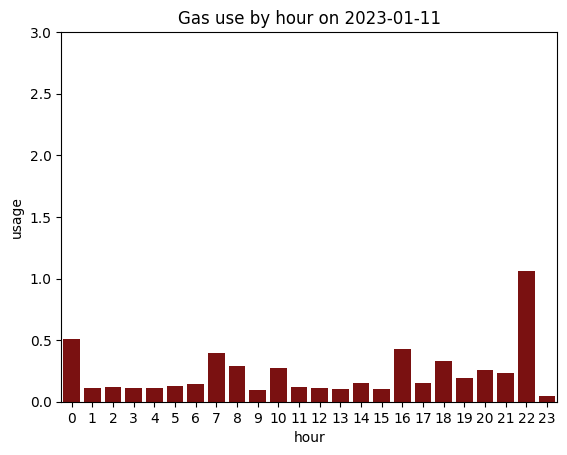

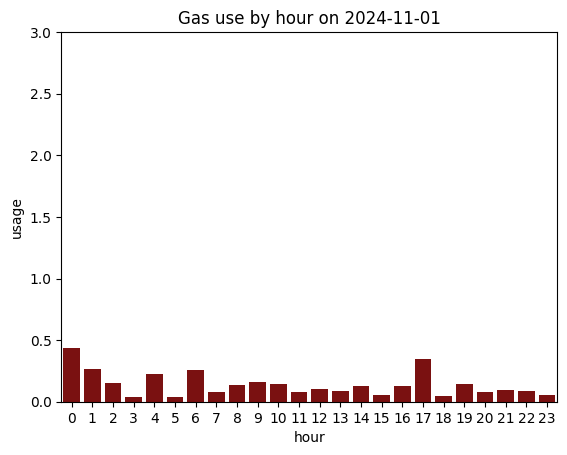

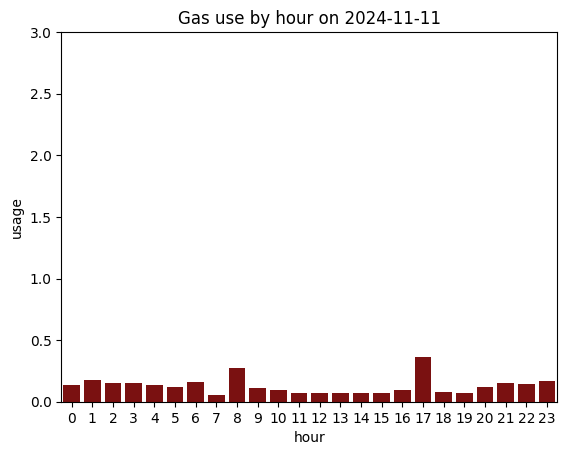

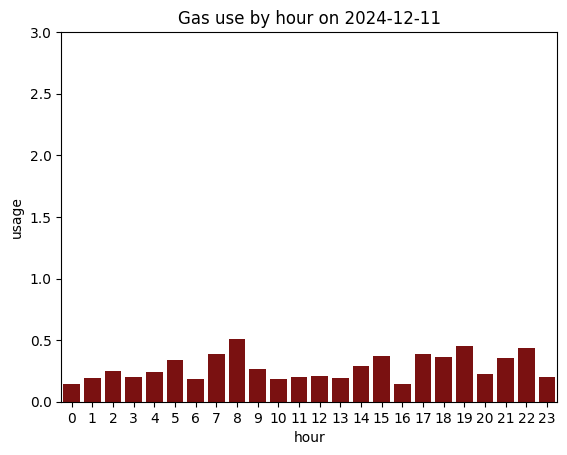

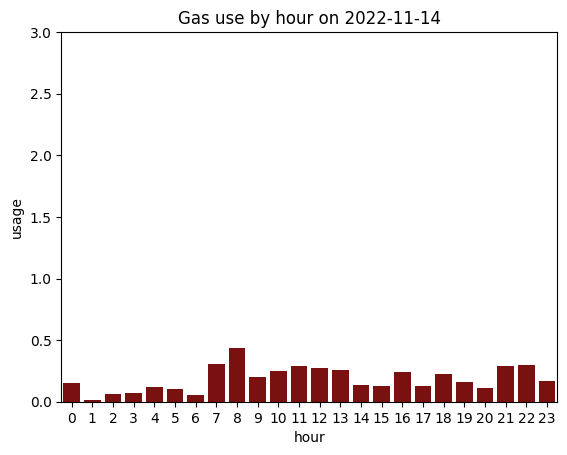

In [36]:
cold_days_gas = gas_usage[gas_usage["date"].isin(random_days)]
cold_days_gas = cold_days_gas[["date", "usage", "hour"]].groupby(["date", "hour"]).sum()

for date in random_days:
    create_day_barplot(cold_days_gas, date, "darkred", "Gas")

#### 2.f: What is the average passive gas use of the house?

As with electricity, we can imagine that the house may use gas "passively" to keep the temperature steady overnight during the winter. This same passive use is expected also when the occupants are not home, as the temperature would still need to be kept steady. However, when occupants are awake and at home, we might imagine that they adjust the temperature to their comfort. We calculate the passive gas consumption of the house below.

Just as before, we see that the lowest gas usage occurs between 01:00 - 05:00, when the occupants are most likely asleep.

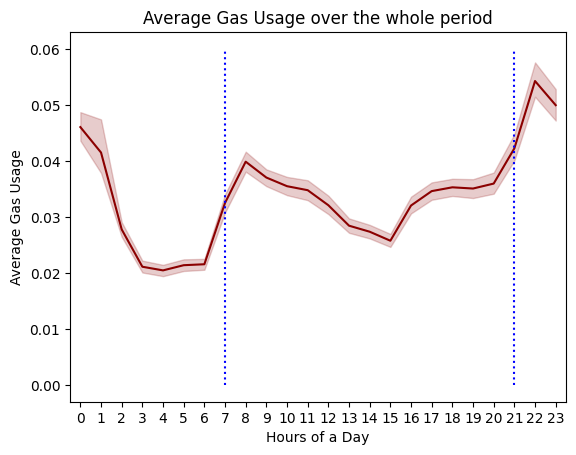

In [40]:
ax = sns.lineplot(gas_usage, x = "hour", y = "usage", estimator= "mean", color = "darkred")
plt.xticks(np.arange(0,24, step = 1), rotation = 0, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.06, linestyles= "dotted", color = "blue")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Gas Usage", title = "Average Gas Usage over the whole period")
plt.show()

#### 2.g: Do the peaks in gas use seen in the above graphs differ significantly from the passive gas use estimates? (Hypothesis-testing using paired-samples t-test)

We check the same dates as we examined for electricity use to see if we can observe similar patterns for the same time intervals and come to a more conclusive result regarding whether those are time-intervals when nobody was home.

First, we check 11th November 2024 (2024-11-01)

For electricity, the peak usage hours seemed to be between 15:00 and 20:00, and this was significantly greater than passive electricity usage. According to the t-test below, as well as the bar-plot, it seems that gas usage is not significantly greater during these times than over the hours of the night when the household would have been expected to be asleep. 

This is also the case for the hours of 09:00 to 14:00. Electricity was also not significantly greater during this interval as well, leading us to conclude that perhaps nobody was home. However, given that gas usage seems to not be significantly greater at any time-interval through the day, this information neither corroborates nor refutes this hypothesis. 

Indeed, perhaps on this day the heating was left on a constant temperature leading to the unpredictable peaks and valleys throughout the day.

Gas use from 15:00 to 20:00 is not significantly greater than passive gas use. p-value = 0.6462217741625711
Gas use from 9:00 to 14:00 is not significantly greater than passive gas use. p-value = 0.7711531543594505


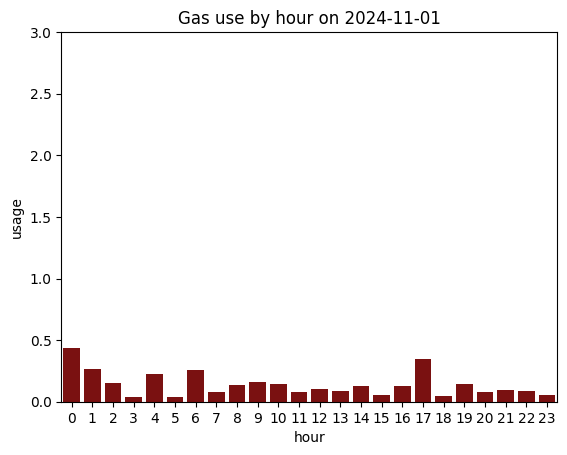

In [41]:
nov_1_gas = gas_usage[gas_usage["date"] == datetime.date(2024,11,1)]
nov_1_gas[["date", "time", "usage", "hour"]]
create_day_barplot(cold_days_gas, datetime.date(2024,11,1), "darkred", "Gas")   

between_hour_t_test(nov_1_gas, peak_hours=list(range(15,21)), possibly_absent_hours=list(range(9,15)), reference_hours=list(range(1,7)), energy = "Gas")


Next, we re-examine 24th November 2024 (2024-11-24). On this date, electricity use between 09:00 and 12:00 was not significantly greater than passive electricity use and this is also the case for gas. This could either indicate either that nobody was home, or that as in the previous examined date, he heating is left at a constant temperature through the day. The latter may seem to be the case as gas usage was not significantly greater also during the peak electricity-usage hours of 19:00 to 22:00.

Gas use from 19:00 to 22:00 is not significantly greater than passive gas use. p-value = 0.9617022468161489
Gas use from 9:00 to 12:00 is not significantly greater than passive gas use. p-value = 0.34369824885489386


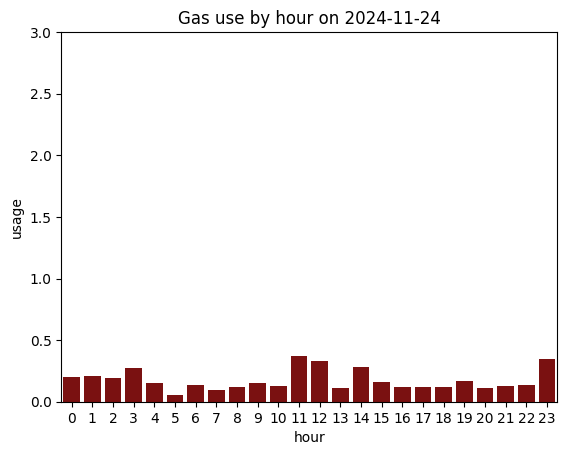

In [42]:
create_day_barplot(cold_days_gas, datetime.date(2024,11,24), "darkred", "Gas")
nov_11_gas = gas_usage[gas_usage["date"] == datetime.date(2024,11,24)]
nov_11_gas[["date", "time", "usage", "hour"]]
between_hour_t_test(nov_11_gas, peak_hours=list(range(19,23)), possibly_absent_hours=list(range(9,13)), reference_hours=list(range(1,5)), energy = "Gas")

For 11th November 2024, it seems there is also no significant difference in gas usage throughout the day. This may indicate that in the colder months, this household keeps a steady temperature by leaving the thermostat on at a constant temperature.

Gas use from 18:00 to 22:00 is not significantly greater than passive gas use. p-value = 0.7846973323206261
Gas use from 10:00 to 14:00 is not significantly greater than passive gas use. p-value = 0.9828095052901042


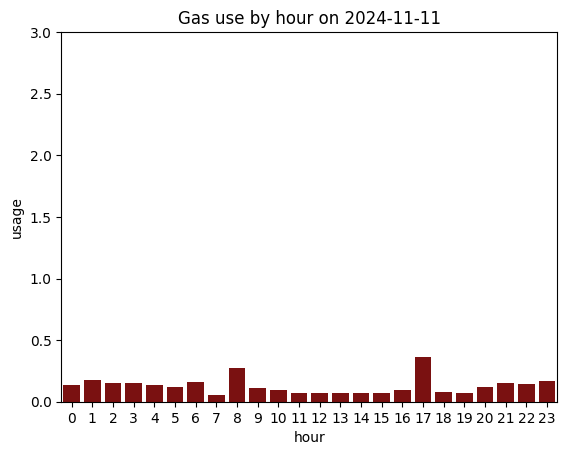

In [43]:
create_day_barplot(cold_days_gas, datetime.date(2024,11,11), "darkred", "Gas")
nov_11_gas = gas_usage[gas_usage["date"] == datetime.date(2024,11,11)]
nov_11_gas[["date", "time", "usage", "hour"]]
between_hour_t_test(nov_11_gas, peak_hours=list(range(18,23)), possibly_absent_hours=list(range(10,15)), reference_hours=list(range(1,6)), energy = "Gas")

#### 2.h: Can the motion sensors indicate when people are home?

Since there are so many entries in the smartthings table, we can fetch data only for the dates and times we are interested in. This can help us check if any of the motion-sensor devices recorded any movement in the house during the times when we suspect people might have been out.

In [15]:
def plot_motion(date):
    df =  db.return_entries_between_dates("smartthings", time_inp = date, dataframe = True)
    return(df)
    '''
    df = df[df["attribute"] == "motion"]
    df = handle_dates_in_df(df)
    df["activation"] = np.where(df["value_str"] == "active", 1, 0)
    df["hour"] = pd.Categorical(df["hour"], categories=range(1,25))
    df_sum = df[["activation", "hour"]].groupby(["hour"], observed=True).sum()
    
    plt.figure()
    sns.barplot(df_sum, x = "hour", y = "activation", color = "darkgreen")
    sns.axes_style()
    title = plt.title(f"Number of motion sensor activations throughout the day on {date}")
    '''


Looking at November 21st 2024, there are, surprisingly, motion sensor recordings as late as 01:00 and as early as 04:00. However, it is clear that when the household is sleeping, there are nearly no (or at least definitely noticeably fewer) motion sensor detections. We also see that one of the peaks of activity measured by motion detection happens at 09:00, meaning that we can definitely say someone was home at that time.

In [16]:
df1 = plot_motion("2024-11-01")
df1

,id,name,epoch,capability,attribute,unit,value_int,value_str
0,1056715,Bathroom (sensor shelf),1730415638,relativeHumidityMeasurement,humidity,%,69.0,None
1,1056716,Kitchen (fridge),1730415639,relativeHumidityMeasurement,humidity,%,59.0,None
2,1056717,Living Room (move),1730415660,motionSensor,motion,None,NaN,active
3,1056718,Kitchen (fridge),1730415680,relativeHumidityMeasurement,humidity,%,60.0,None
4,1056719,Kitchen (fridge),1730415720,relativeHumidityMeasurement,humidity,%,61.0,None
...,...,...,...,...,...,...,...,...
2359,1059074,Bathroom (sensor eye),1730501790,motionSensor,motion,None,NaN,active
2360,1059075,Bathroom (sensor eye),1730501860,motionSensor,motion,None,NaN,inactive
2361,1059076,Bathroom (sensor eye),1730501860,motionSensor,motion,None,NaN,active
2362,1059077,Bathroom (sensor eye),1730501907,illuminanceMeasurement,illuminance,lux,58.0,None


Next, looking at 24th November, we can see that there appears to have been no activity in the house during one of the hours when we suspected no occupants were at home. At 09:00, no motion detection took place, meaning that it is likely no one was home during that single hour. However, this plot also indicates that there was someone at home during the rest of the interval (from 10:00 to 12:00). What is also interesting is that there is movement in the house in the middle of the night (02:00 and 03:00). This could either indicate that people were awake, or that there are pets who do not sleep through the whole night in the household.

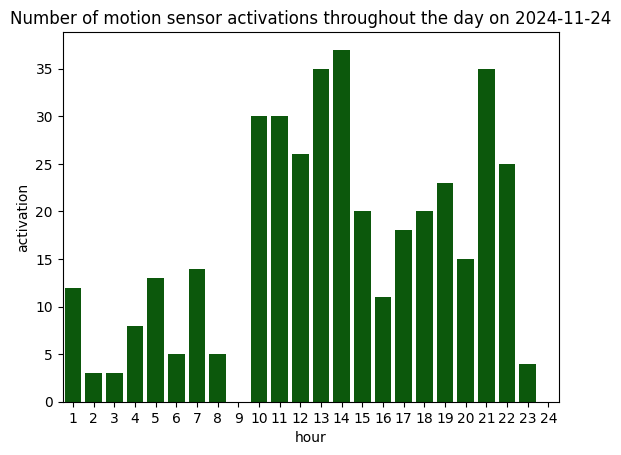

In [46]:
plot_motion("2024-11-24")

Finally, on November 11th we see that there was indeed a period of time during the day when no motion was detected. However, this was not exactly during the interval when the low electricity use was spotted (10:00 - 14:00). The first absence appears to have happened from 09:00 to 10:00, then there is some activity from 10:00 to 11:00, and once again, no activity from 11:00 to 12:00. The rest of the day, movement is recorded in the house. Coupled with the previous observations, it appears that this is a family with members who work from home -- and thus are home almost every day for almost the entire day, who may also have a pet whom they like to take for walks at 09:00, or who leave the home briefly, usually in the morning.

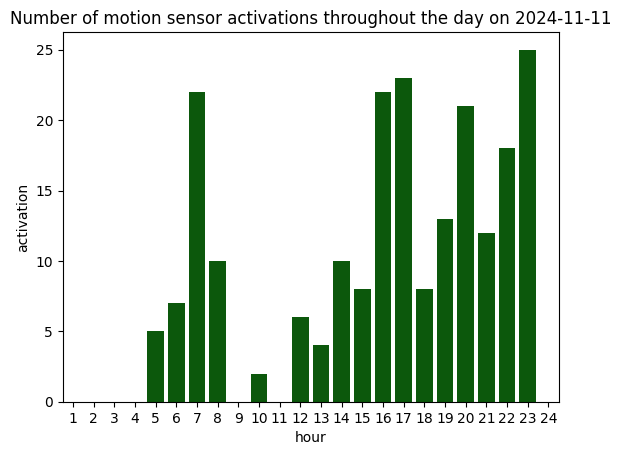

In [47]:
plot_motion("2024-11-11")

Overall, it appears that the easiest way to check whether someone is home is to check the motion-sensor data. 